# Esercizio libero, parte 0 e parte 1

Sei l'analista dati di **"BookShop"**, una libreria online italiana con 3 categorie di prodotto (*Narrativa*, *Saggistica*, *Bambini*) e 4 mesi di vendite (*Gennaio–Aprile 2024*).

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns


-------------------------------------------------------
PARTE 1 - Dataset BookShop (già pronto)
-------------------------------------------------------

[1.1] Vendite per categoria:
 Narrativa    = €18,400 | 920 ordini | prezzo medio €20.0
 Saggistica   = €12,700 | 540 ordini | prezzo medio €23.5
 Bambini      = €9,300 | 410 ordini | prezzo medio €22.7


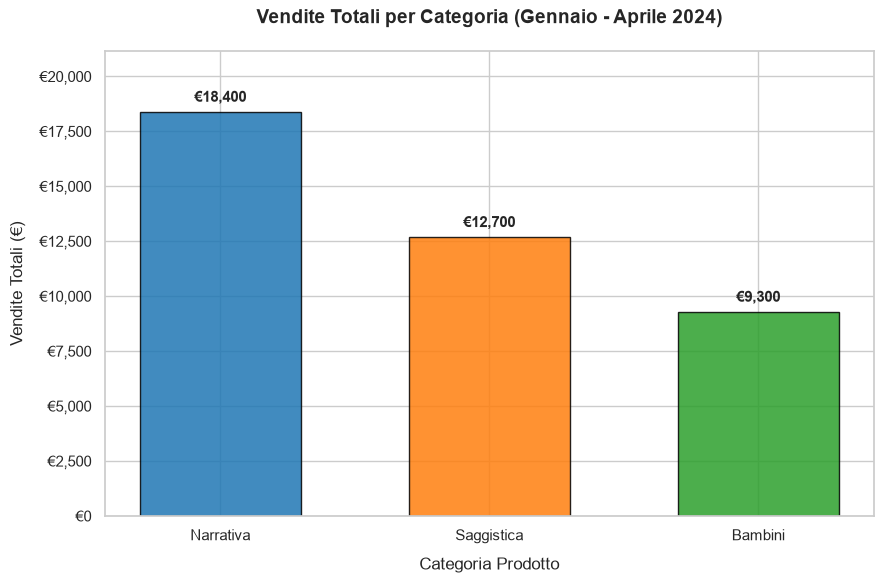

In [13]:
# PARTE 1 - DATI GIÀ PRONTI
# =========================================================================
# Leggi attentamente i dati: capire cosa rappresenta ogni variabile
# è il PRIMO passo prima di disegnare qualsiasi grafico. [08.1]

print("\n" + "-"*55)
print("PARTE 1 - Dataset BookShop (già pronto)")
print("-"*55)

np.random.seed(2024)

# -- Dati aggregati per categoria (per IL GRAFICO A BARRE) ----------------
categorie        = ["Narrativa", "Saggistica", "Bambini"]
vendite_totali   = [18400, 12700, 9300]     # € totali in 4 mesi
n_ordini         = [920, 540, 410]          # numero di ordini
prezzo_medio     = [20.0, 23.5, 22.7]       # prezzo medio per ordine (€)

print("\n[1.1] Vendite per categoria:")
for i, cat in enumerate(categorie):
    print(f" {cat:12s} = €{vendite_totali[i]:,.0f} | "
          f"{n_ordini[i]} ordini | prezzo medio €{prezzo_medio[i]:.1f}")

# =================
# GRAFICO A BARRE
# ================

# Imposta lo stile di Seaborn
sns.set_theme(style="whitegrid")

# Crea la figura
plt.figure(figsize=(9, 6))

# Disegna il grafico a barre con una palette di colori curata
colori = ['#1f77b4', '#ff7f0e', '#2ca02c']
barre = plt.bar(categorie, vendite_totali, color=colori, edgecolor='black', alpha=0.85, width=0.6)

# Aggiunge i valori esatti sopra ogni barra
for barra in barre:
    altezza = barra.get_height()
    plt.text(barra.get_x() + barra.get_width()/2., altezza + 300,
             f'€{altezza:,.0f}',
             ha='center', va='bottom', fontsize=11, fontweight='bold')

# Titoli e label degli assi
plt.title("Vendite Totali per Categoria (Gennaio - Aprile 2024)", fontsize=14, pad=20, fontweight='bold')
plt.xlabel("Categoria Prodotto", fontsize=12, labelpad=10)
plt.ylabel("Vendite Totali (€)", fontsize=12, labelpad=10)

# Formatta l'asse Y per mostrare il simbolo dell'Euro (€) e i separatori delle migliaia
formatter = ticker.FuncFormatter(lambda x, pos: f"€{x:,.0f}")
plt.gca().yaxis.set_major_formatter(formatter)

# Regola il limite dell'asse Y per lasciare spazio alle etichette sopra le barre
plt.ylim(0, max(vendite_totali) * 1.15)

# Ottimizza i margini e mostra il grafico
plt.tight_layout()
plt.show()




[1.2] Prezzi ordini: 400 osservazioni
 Media   : €20.99
 Mediana : €20.62
 Min     : €5.00
 Max     : €38.34


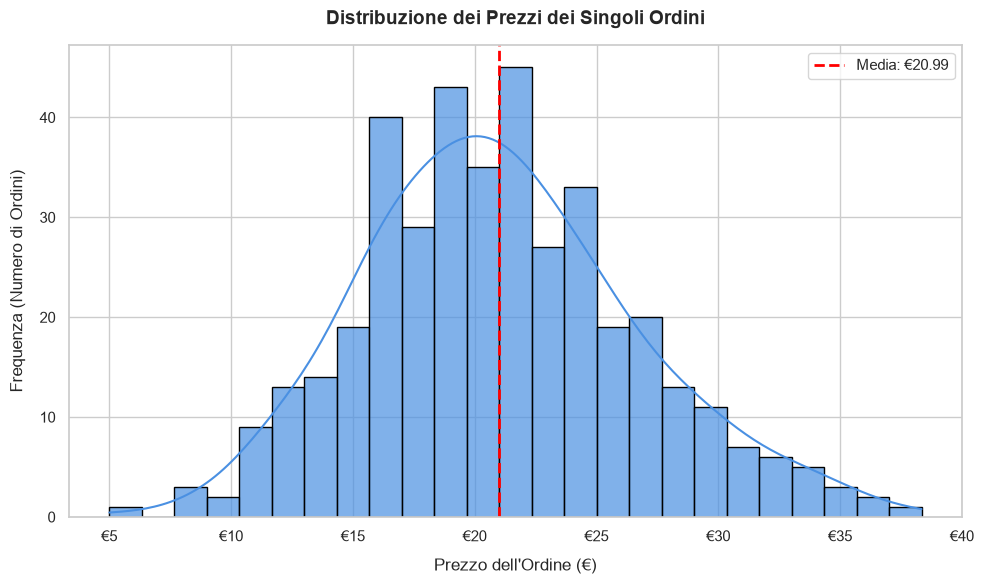

In [11]:
# -- Distribuzione prezzi singoli ordini (per L'ISTOGRAMMA) ---------------
# 400 ordini con prezzi realistici per una libreria online
prezzi_ordini = np.concatenate([
    np.random.normal(18, 4, 160),     # Narrativa: media 18€
    np.random.normal(24, 6, 140),     # Saggistica: media 24€
    np.random.normal(21, 5, 100),     # Bambini: media 21€
]).clip(5, 60).round(2)               # nessun prezzo sotto 5€ o sopra 60€

print(f"\n[1.2] Prezzi ordini: {len(prezzi_ordini)} osservazioni")
print(f" Media   : €{prezzi_ordini.mean():.2f}")
print(f" Mediana : €{np.median(prezzi_ordini):.2f}")
print(f" Min     : €{prezzi_ordini.min():.2f}")
print(f" Max     : €{prezzi_ordini.max():.2f}")

# =========================
# CREAZIONE DEL ISTOGRAMMA
# ========================= 


# Imposta lo stile di Seaborn
sns.set_theme(style="whitegrid")

# Crea la figura
plt.figure(figsize=(10, 6))

# Disegna l'istogramma con una curva KDE (stima della densità della curva) per vedere l'andamento
sns.histplot(prezzi_ordini, bins=25, kde=True, color='#4a90e2', edgecolor='black', alpha=0.7)

# Aggiunge una linea verticale per indicare la media dei prezzi
media_prezzi = prezzi_ordini.mean()
plt.axvline(media_prezzi, color='red', linestyle='--', linewidth=2, 
            label=f'Media: €{media_prezzi:.2f}')

# Titoli e label degli assi
plt.title("Distribuzione dei Prezzi dei Singoli Ordini", fontsize=14, pad=15, fontweight='bold')
plt.xlabel("Prezzo dell'Ordine (€)", fontsize=12, labelpad=10)
plt.ylabel("Frequenza (Numero di Ordini)", fontsize=12, labelpad=10)

# Formatta l'asse X per mostrare il simbolo dell'Euro (€)
formatter = ticker.FuncFormatter(lambda x, pos: f"€{x:,.0f}")
plt.gca().xaxis.set_major_formatter(formatter)

# Mostra la legenda (necessaria per la linea della media)
plt.legend(fontsize='11', loc='upper right')

# Ottimizza i margini e mostra il grafico
plt.tight_layout()
plt.show()


[1.3] Vendite mensili per categoria (€):
   Mese            Narrativa   Saggistica    Bambini
   Gennaio             4,200        3,100      2,800
   Febbraio            3,800        2,900      2,400
   Marzo               5,100        3,400      1,900
   Aprile              5,300        3,300      2,200


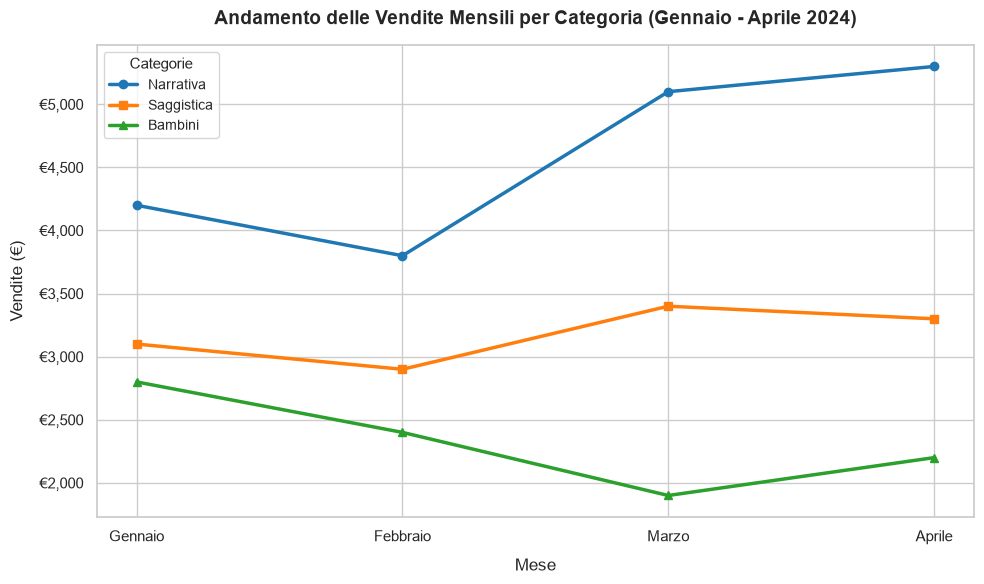

In [ ]:
# -- Vendite mensili per categoria (per IL GRAFICO LINEARE) ---------------
mesi              = ["Gennaio", "Febbraio", "Marzo", "Aprile"]
vendite_narrativa = [4200, 3800, 5100, 5300]
vendite_saggistica = [3100, 2900, 3400, 3300]
vendite_bambini   = [2800, 2400, 1900, 2200]

print("\n[1.3] Vendite mensili per categoria (€):")
print(f"   {'Mese':12s} {'Narrativa':>12s} {'Saggistica':>12s} {'Bambini':>10s}")
for i, mese in enumerate(mesi):
    print(f"   {mese:12s} "
          f"{vendite_narrativa[i]:>12,.0f} "
          f"{vendite_saggistica[i]:>12,.0f} "
          f"{vendite_bambini[i]:>10,.0f}")

# ===============================
# CREAZIONE DEL GRAFICO LINEARE
# ===============================
# Imposta lo stile di Seaborn per una grafica più pulita
sns.set_theme(style="whitegrid")

# Crea la figura e l'asse
plt.figure(figsize=(10, 6))

# Disegna le linee per ogni categoria con marker per evidenziare i mesi
plt.plot(mesi, vendite_narrativa, marker='o', linewidth=2.5, label='Narrativa', color='#1f77b4')
plt.plot(mesi, vendite_saggistica, marker='s', linewidth=2.5, label='Saggistica', color='#ff7f0e')
plt.plot(mesi, vendite_bambini, marker='^', linewidth=2.5, label='Bambini', color='#2ca02c')

# Aggiungi titolo e costumizza le etichette degli assi
plt.title("Andamento delle Vendite Mensili per Categoria (Gennaio - Aprile 2024)", fontsize=14, pad=15, fontweight='bold')
plt.xlabel("Mese", fontsize=12, labelpad=10)
plt.ylabel("Vendite (€)", fontsize=12, labelpad=10)

# Formatta l'asse Y per mostrare il simbolo dell'Euro (€) e il separatore delle migliaia
formatter = ticker.FuncFormatter(lambda x, pos: f"€{x:,.0f}")
plt.gca().yaxis.set_major_formatter(formatter)

# Mostra la legenda in una posizione ottimale
plt.legend(title="Categorie", title_fontsize='11', fontsize='10', loc='upper left')

# Ottimizza i margini e mostra il grafico
plt.tight_layout()
plt.show()

# Esercizio (1/2)

**Scenario:** sei l'analista dati di *"SportZone"*, una catena di negozi di articoli sportivi con 4 punti vendita in Italia. Il direttore ti consegna i dati grezzi delle vendite degli ultimi 6 mesi e ti chiede di **TRASFORMARLI** e poi **VISUALIZZARLI** in 4 grafici chiave.

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Seed fisso: tutti otterranno lo stesso dataset
np.random.seed(42)

n = 300

negozi        = ["Roma", "Milano", "Napoli", "Torino"]
categorie     = ["Running", "Nuoto", "Palestra", "Outdoor", "Team Sport"]
fasce_clienti = ["Principiante", "Intermedio", "Avanzato"]

df_raw = pd.DataFrame({
    "data": pd.date_range("2024-01-05", periods=n, freq="15h"),
    
    "negozio": np.random.choice(
        negozi, n, p=[0.30, 0.28, 0.22, 0.20]
    ),
    "categoria": np.random.choice(
        categorie, n, p=[0.25, 0.18, 0.22, 0.20, 0.15]
    ),
    "cliente_fascia": np.random.choice(
        fasce_clienti, n, p=[0.35, 0.40, 0.25]
    ),
    "prezzo_listino": np.round(
        np.random.choice(
            [29.9, 49.9, 79.9, 119.9, 189.9, 249.9], n,
            p=[0.20, 0.25, 0.22, 0.18, 0.10, 0.05]
        ) + np.random.normal(0, 8, n), 2
    ).clip(15, 300),
    
    "quantita": np.random.randint(1, 6, n),
    
    "sconto_pct": np.random.choice(
        [0, 5, 10, 15, 20, 30, 40], n,
        p=[0.30, 0.15, 0.20, 0.15, 0.10, 0.07, 0.03]
    ),
    "costo_acquisto": np.round(
        np.random.uniform(0.40, 0.65, n), 2
    )
})

print(f"Dataset caricato: {df_raw.shape[0]} righe x {df_raw.shape[1]} colonne")
df_raw.head(8)
print("FORZA LIONEL")

Dataset caricato: 300 righe x 8 colonne
FORZA LIONEL


## 1. Ispezionare il dataset

In [16]:
# Numero di righe e colonne
print(f"Il dataset ha {df_raw.shape[0]} righe e {df_raw.shape[1]} colonne.")

# Controllo dei valori mancanti
print("\nValori mancanti per colonna:")
print(df_raw.isnull().sum())

# Prezzo medio di listino
prezzo_medio_listino = df_raw['prezzo_listino'].mean()
print(f"\nIl prezzo medio di listino è: €{prezzo_medio_listino:.2f}")

Il dataset ha 300 righe e 8 colonne.

Valori mancanti per colonna:
data              0
negozio           0
categoria         0
cliente_fascia    0
prezzo_listino    0
quantita          0
sconto_pct        0
costo_acquisto    0
dtype: int64

Il prezzo medio di listino è: €94.57


## 2. Aggiungere colonne calcolate

In [17]:
df = df_raw.copy()

# 1. Prezzo dopo lo sconto
df['prezzo_scontato'] = df['prezzo_listino'] * (1 - df['sconto_pct'] / 100)

# 2. Fatturato (prezzo scontato * quantità)
df['fatturato'] = df['prezzo_scontato'] * df['quantita']

# 3. Costo totale sostenuto dal negozio (basato sul prezzo di listino o sul fatturato? 
# Generalmente il costo d'acquisto è una percentuale del listino originario)
df['costo_totale'] = df['prezzo_listino'] * df['costo_acquisto'] * df['quantita']

# 4. Margine assoluto in euro
df['margine_assoluto'] = df['fatturato'] - df['costo_totale']

# 5. Margine percentuale
df['margine_percentuale'] = (df['margine_assoluto'] / df['fatturato']) * 100

df.head()

,data,negozio,categoria,cliente_fascia,prezzo_listino,quantita,sconto_pct,costo_acquisto,prezzo_scontato,fatturato,costo_totale,margine_assoluto,margine_percentuale
0,2024-01-05 00:00:00,Milano,Running,Principiante,62.42,4,0,0.62,62.420,249.680,154.8016,94.8784,38.000000
1,2024-01-05 15:00:00,Torino,Palestra,Principiante,29.37,3,0,0.56,29.370,88.110,49.3416,38.7684,44.000000
2,2024-01-06 06:00:00,Napoli,Palestra,Principiante,25.46,2,30,0.44,17.822,35.644,22.4048,13.2392,37.142857
3,2024-01-06 21:00:00,Napoli,Palestra,Principiante,94.95,1,0,0.51,94.950,94.950,48.4245,46.5255,49.000000
4,2024-01-07 12:00:00,Roma,Outdoor,Principiante,38.32,5,15,0.55,32.572,162.860,105.3800,57.4800,35.294118


## 3. Usare GroupBy con aggregazione multipla

In [18]:
# Estraiamo il mese dalla colonna data per il trend temporale
df['mese'] = df['data'].dt.strftime('%B')

# Aggregazione 1: Per Categoria
agg_categoria = df.groupby('categoria').agg(
    fatturato_totale=('fatturato', 'sum'),
    margine_medio=('margine_percentuale', 'mean'),
    numero_transazioni=('fatturato', 'count'),
    sconto_medio=('sconto_pct', 'mean')
)
print("--- Aggregazione per Categoria ---")
print(agg_categoria, "\n")

# Aggregazione 2: Per Negozio
agg_negozio = df.groupby('negozio').agg(
    fatturato_totale=('fatturato', 'sum'),
    margine_totale=('margine_assoluto', 'sum'),
    fatturato_medio=('fatturato', 'mean')
)
print("--- Aggregazione per Negozio ---")
print(agg_negozio, "\n")

# Aggregazione 3: Per Negozio + Mese (Trend temporale)
agg_negozio_mese = df.groupby(['negozio', 'mese']).agg(
    fatturato_totale=('fatturato', 'sum')
).reset_index()
print("--- Aggregazione per Negozio + Mese (Prime 5 righe) ---")
print(agg_negozio_mese.head())

--- Aggregazione per Categoria ---
            fatturato_totale  margine_medio  numero_transazioni  sconto_medio
categoria                                                                    
Nuoto             11029.3025      41.286189                  48      9.270833
Outdoor           15234.0100      37.701998                  53     13.207547
Palestra          19662.2595      41.709569                  70     10.500000
Running           21076.5260      42.215769                  75      9.200000
Team Sport        11504.6880      39.992539                  54      9.629630 

--- Aggregazione per Negozio ---
         fatturato_totale  margine_totale  fatturato_medio
negozio                                                   
Milano         18327.8880       7511.9774       238.024519
Napoli         16127.0245       6260.5977       248.108069
Roma           26954.3340      11779.8973       283.729832
Torino         17097.5395       7489.6772       271.389516 

--- Aggregazione per Negozio

## 4. Costruire una Pivot Table

In [19]:
# Ordine cronologico dei mesi per una corretta visualizzazione
ordine_mesi = ["January", "February", "March", "April", "May", "June"]
df['mese'] = pd.Categorical(df['data'].dt.strftime('%B'), categories=ordine_mesi, ordered=True)

# Pivot 1: Fatturato totale per negozio x mese
pivot_fatturato = df.pivot_table(
    values='fatturato', 
    index='negozio', 
    columns='mese', 
    aggfunc='sum', 
    margins=True
)
print("--- Pivot Fatturato (con Totali) ---")
display(pivot_fatturato)

# Pivot 2: Margine percentuale medio per categoria x negozio
pivot_margine = df.pivot_table(
    values='margine_percentuale', 
    index='categoria', 
    columns='negozio', 
    aggfunc='mean'
)
print("\n--- Pivot Margine Percentuale Medio ---")
display(pivot_margine)

# Risposta al quesito: Quale negozio ha il fatturato più alto a marzo?
# Nota: "March" se l'output usa i mesi in inglese di pandas
negozio_top_marzo = pivot_fatturato['March'].drop('All').idxmax()
valore_top_marzo = pivot_fatturato['March'].drop('All').max()
print(f"\nIl negozio con il fatturato più alto a Marzo è {negozio_top_marzo} con €{valore_top_marzo:,.2f}")

--- Pivot Fatturato (con Totali) ---


C:\Users\A1627apulia\AppData\Local\Temp\ipykernel_14260\1667039280.py:3: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  df['mese'] = pd.Categorical(df['data'].dt.strftime('%B'), categories=ordine_mesi, ordered=True)


mese,January,February,March,April,May,June,All
negozio,,,,,,,
Milano,2757.2890,3275.8855,2946.8810,2683.5330,2281.968,2924.9385,16870.4950
Napoli,1498.5100,1769.4800,1423.4180,3605.6065,4618.542,1945.7240,14861.2805
Roma,3953.5575,3082.4190,4125.5215,5526.5970,6130.915,1603.4560,24422.4660
Torino,1162.2650,1931.1350,3509.3130,2560.7465,2613.029,5205.9110,16982.3995
All,9371.6215,10058.9195,12005.1335,14376.4830,15644.454,11680.0295,73136.6410



--- Pivot Margine Percentuale Medio ---


negozio,Milano,Napoli,Roma,Torino
categoria,,,,
Nuoto,42.879671,37.096100,42.991095,41.313725
Outdoor,36.367441,35.778083,37.023501,42.539822
Palestra,43.563279,37.019592,42.730263,42.684215
Running,40.461327,44.528449,42.237494,41.858742
Team Sport,37.571631,40.203347,41.457129,38.992997



Il negozio con il fatturato più alto a Marzo è Roma con €4,125.52


## 5. Filtrare righe con condizioni booleane

In [20]:
# Condizione 1: Transazioni con sconto >= 20%
df_sconto_20 = df[df['sconto_pct'] >= 20]
print(f"Numero di transazioni con sconto >= 20%: {len(df_sconto_20)}")

# Condizione 2: Transazioni del negozio di Roma nella sola categoria Running
df_roma_running = df[(df['negozio'] == 'Roma') & (df['categoria'] == 'Running')]
print(f"Numero di transazioni a Roma per la categoria Running: {len(df_roma_running)}")

Numero di transazioni con sconto >= 20%: 57
Numero di transazioni a Roma per la categoria Running: 24


## 6. Creare un Istogramma

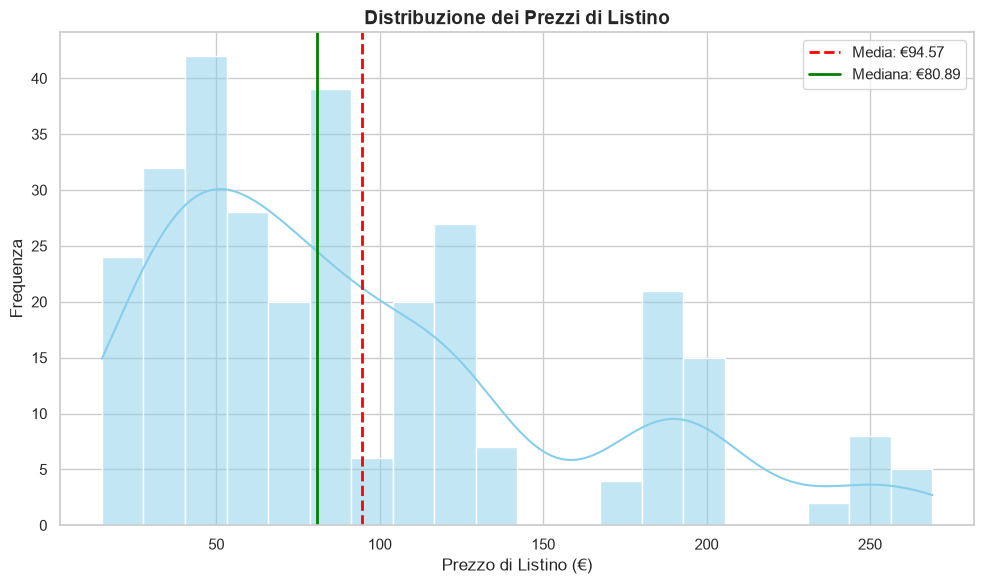

In [21]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.histplot(data=df, x='prezzo_listino', bins=20, kde=True, color='skyblue', ax=ax)

media = df['prezzo_listino'].mean()
mediana = df['prezzo_listino'].median()

# Linee verticali
ax.axvline(media, color='red', linestyle='--', linewidth=2, label=f'Media: €{media:.2f}')
ax.axvline(mediana, color='green', linestyle='-', linewidth=2, label=f'Mediana: €{mediana:.2f}')

ax.set_title("Distribuzione dei Prezzi di Listino", fontsize=14, fontweight='bold')
ax.set_xlabel("Prezzo di Listino (€)")
ax.set_ylabel("Frequenza")
ax.legend()
plt.tight_layout()
plt.show()

## 7. Creare un Grafico a Barre (Subplots 1, 2)

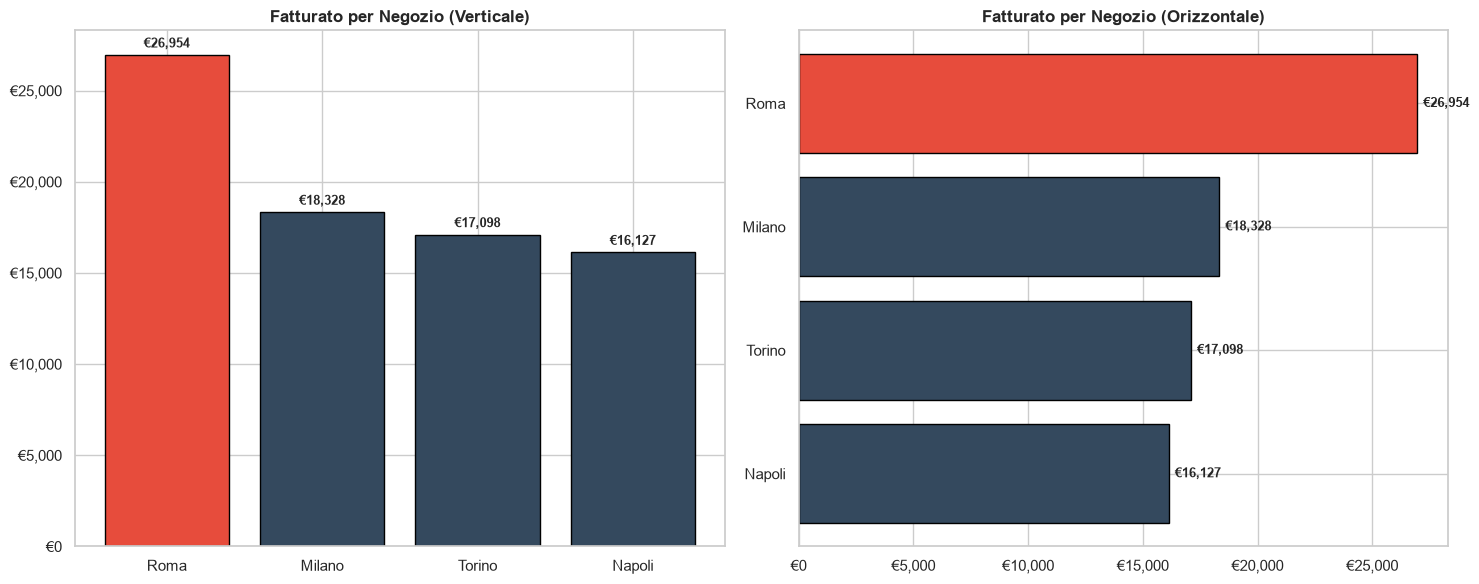

In [22]:
# Prepariamo i dati delle vendite per negozio
dati_barre = df.groupby('negozio')['fatturato'].sum().reset_index()
dati_barre = dati_barre.sort_values(by='fatturato', ascending=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Individuiamo l'indice della barra più alta per evidenziarla
negozio_max = dati_barre.iloc[0]['negozio']
colori = ['#e74c3c' if x == negozio_max else '#34495e' for x in dati_barre['negozio']]

# --- Grafico 1: Barre Verticali ---
barre_v = ax1.bar(dati_barre['negozio'], dati_barre['fatturato'], color=colori, edgecolor='black')
ax1.set_title("Fatturato per Negozio (Verticale)", fontweight='bold')
ax1.yaxis.set_major_formatter(mticker.StrMethodFormatter('€{x:,.0f}'))

# Etichette sopra le barre
for bar in barre_v:
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, yval + (max(dati_barre['fatturato'])*0.01), 
             f"€{yval:,.0f}", ha='center', va='bottom', fontsize=9, fontweight='bold')

# --- Grafico 2: Barre Orizzontali ---
barre_h = ax2.barh(dati_barre['negozio'], dati_barre['fatturato'], color=colori, edgecolor='black')
ax2.set_title("Fatturato per Negozio (Orizzontale)", fontweight='bold')
ax2.xaxis.set_major_formatter(mticker.StrMethodFormatter('€{x:,.0f}'))
ax2.invert_yaxis() # Per avere il più alto in alto

# Etichette accanto alle barre
for bar in barre_h:
    xval = bar.get_width()
    ax2.text(xval + (max(dati_barre['fatturato'])*0.01), bar.get_y() + bar.get_height()/2, 
             f"€{xval:,.0f}", ha='left', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

## 8. Creare un Grafico Lineare (Trend Temporale)

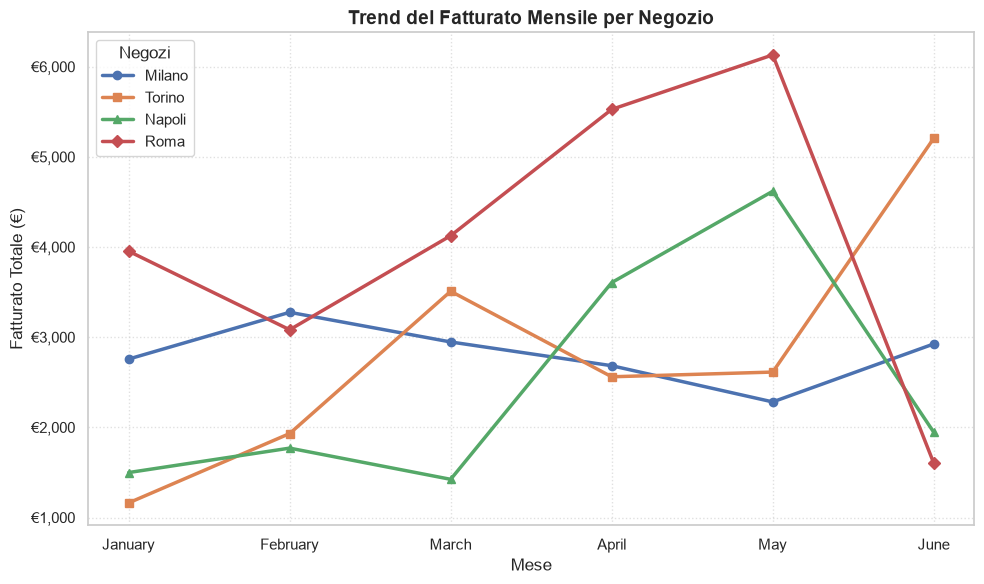

In [23]:
# Ricreiamo il raggruppamento per negozio e mese assicurandoci dell'ordine corretto
df_trend = df.groupby(['negozio', 'mese'], observed=False)['fatturato'].sum().reset_index()

fig, ax = plt.subplots(figsize=(10, 6))

# Lista di marker diversi da assegnare nel ciclo for
markers = ['o', 's', '^', 'D']

for i, negozio in enumerate(df['negozio'].unique()):
    dati_negozio = df_trend[df_trend['negozio'] == negozio]
    ax.plot(dati_negozio['mese'], dati_negozio['fatturato'], 
            marker=markers[i % len(markers)], linewidth=2.5, label=negozio)

ax.set_title("Trend del Fatturato Mensile per Negozio", fontsize=14, fontweight='bold')
ax.set_xlabel("Mese")
ax.set_ylabel("Fatturato Totale (€)")
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter('€{x:,.0f}'))
ax.legend(title="Negozi")
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

## 9. Creare uno Scatter Plot

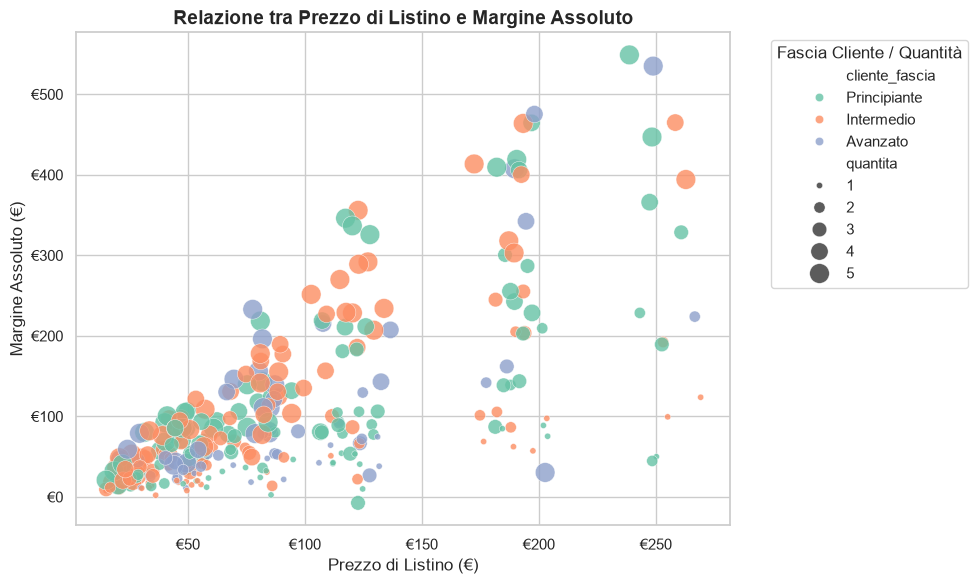

: 

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

# Scatter plot: Relazione tra Prezzo di listino e Margine Assoluto, colorato per Fascia Cliente
sns.scatterplot(
    data=df, 
    x='prezzo_listino', 
    y='margine_assoluto', 
    hue='cliente_fascia', 
    size='quantita',
    sizes=(20, 200),
    palette='Set2', 
    alpha=0.8,
    ax=ax
)

ax.set_title("Relazione tra Prezzo di Listino e Margine Assoluto", fontsize=14, fontweight='bold')
ax.set_xlabel("Prezzo di Listino (€)")
ax.set_ylabel("Margine Assoluto (€)")
ax.xaxis.set_major_formatter(mticker.StrMethodFormatter('€{x:,.0f}'))
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter('€{x:,.0f}'))

ax.legend(title="Fascia Cliente / Quantità", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()